In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

¿Qué representan las features medidas por el radar? ¿Son todas numéricas?
¿Es necesario algún tipo de normalización o escalado previo al entrenamiento
de la red?
Los datos representados en el archivo ionosphere.data representan los retornos de un radar, cada medicion (fila) debera ser clasificada como adecuada o no adecuada para el analisis posterior, los datos de este archivo son numericos y no numericos.
Tenemos que es recomendable realizar un escalado previo para el entrenamiento de una red neuronal, ya que estos colaboran en mejorar el rendimiento de la red para alcanzar la prediccion de los datos de una manera correcta, es decir, existe un menor error.

In [ ]:
datos = pd.DataFrame(pd.read_csv('ionosphere.data'))
datos=datos.dropna()


Determinar si los datos están balanceados. Si hay desbalance, ¿Qué técnica se
podría elegir para corregirlo de acuerdo a las ventajas y desventajas que tienen
cada una de las siguientes técnicas: undersampling, oversampling, SMOTE
(Synthetic Minority Over-sampling Technique), data augmentation? Existe un desbalance, ya que se encuentran 224 datos de la 'clase' g y de la 'clase' b se encuentran 126. Este desbalance, va a poder infligir en la prediccion de la red neuronal, la misma va a ser entrenada de una manera incorrecta, donde aprendera a poder predecir cierta clase, y no podra predecir la otra de una manera correcta.

*** TECNICAS ***
    
    undersampling: En la utilizacion de esta tecnica se buscara reducir la clase mayoritaria, existe la tecnica de undersampling aleatoria, que elimina una cantidad de muestras de la clase mayoritaria, hasta que la misma este balanceada con la clase minoritaria, la misma elimina muestras aleatorias. La vetaja de esta es que reduce el tiempo de entrenamiento de una manera significativa. la desventaja de esta es que se pierde informacion al eliminar datos que pueden ser significativos para el entrenamiento del modelo, ademas que hay un sesgo de seleccion ya que puede ser que el conjunto de datos sea no significativo respecto al problema que se intenta representar.
    
    Oversampling: La tecnica de oversampling, consiste en rellenar la clase minoritaria hasta que esta este balanceada con la clase mayoritaria, la misma introduce muestras "sinteticas", la principal ventaja es que no se pierde informacion, pero una desventaja es que el agregado de muestras puede ser erroneo y producir overfitting, en caso de que se multipliquen las muestras de la clase minoritaria.
    
    SMOTE: El algoritmo SMOTE(Synthetic Minority Over-sampling Technique) es un algoritmo que busca arreglar el desbalanciamiento entre dos clases, lo que hace es utilizar oversampling (en algunos casos de la combina con Tomek links, que elimina los vecinos mas cercanos entre la clase mayoritaria y la minoritaria y elimina los puntos de la mayoritaria), donde se aumenta la cantidad de muestra de la clase minoritaria, agregando la muestra de la clase minoritaria, de una manera sintetica(se calcula la distancia entre los puntos de la clase minoritaria, y en esa distancia, se va agregando los puntos faltantes)

['b' 'g']
Cantidad de muestras de la clase g original :  224
Cantidad de muestras de la clase b original 126
Cantidad de muetsras de la clase g, aplicando smote 224
Cantidad de muetsras de la clase b, aplicando smote 224


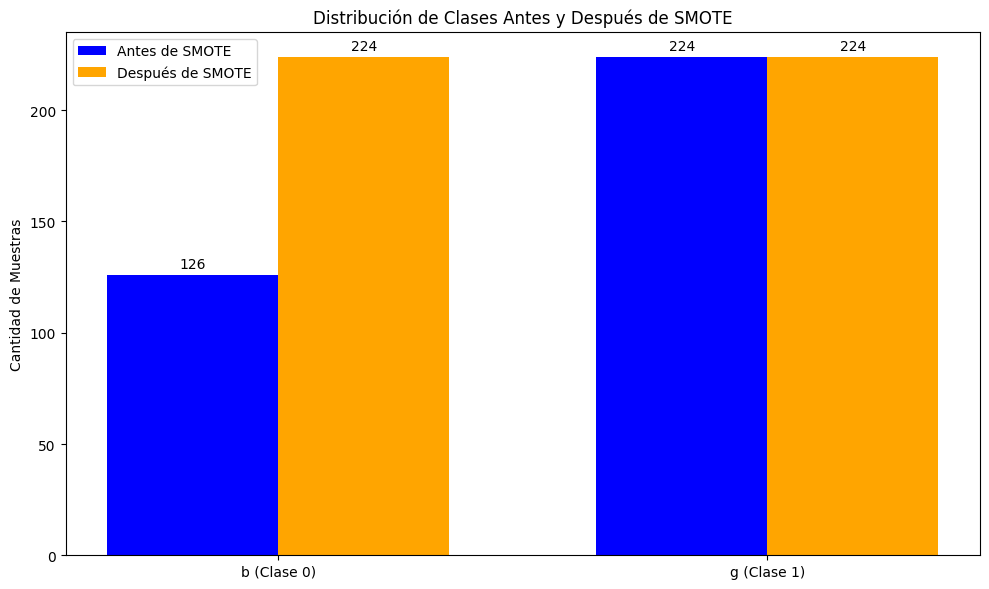

In [ ]:
print(datos['g'].unique())
mapeo = {'g': 1 , 'b': 0}

X = datos.drop(columns='g')
Y = datos['g'] #y van a ser los datos que indica si es de g o de b
Y = Y.map(mapeo) # reemplazo los valores no numericos por 1 y 0

originalG=[(Y == 1).sum(), (Y == 0).sum()]

print('Cantidad de muestras de la clase g original : ', originalG[0])
print('Cantidad de muestras de la clase b original', originalG[1])



smote = SMOTE(random_state=42)

X, Y = smote.fit_resample(X,Y) #aplico smote a los datos, para que esten balanceados

balanceadosG= [(Y == 1).sum(), (Y == 0).sum()]


print('Cantidad de muetsras de la clase g, aplicando smote', balanceadosG[0])
print('Cantidad de muetsras de la clase b, aplicando smote', balanceadosG[1])


labels = ['b (Clase 0)', 'g (Clase 1)']
counts_before = [originalG[1], originalG[0]]  # Datos ANTES de SMOTE
counts_after = [balanceadosG[1], balanceadosG[0]] # Datos DESPUÉS de SMOTE

# 2. Definir la posición y el ancho de las barras
x_positions = [0, 1]  # Ubicaciones en el eje X para los grupos
width = 0.35      # Ancho de cada barra

# 3. Crear la figura y los ejes
fig, ax = plt.subplots(figsize=(10, 6))

# 4. Dibujar las barras
# Barras para "Antes de SMOTE" (en azul, como en tu imagen de ejemplo)
rects1 = ax.bar(
    [pos - width/2 for pos in x_positions],
    counts_before,
    width,
    label='Antes de SMOTE',
    color='blue'
)
# Barras para "Después de SMOTE" (en naranja, como en tu imagen)
rects2 = ax.bar(
    [pos + width/2 for pos in x_positions],
    counts_after,
    width,
    label='Después de SMOTE',
    color='orange'
)

# 5. Añadir etiquetas, título y leyenda
ax.set_ylabel('Cantidad de Muestras')
ax.set_title('Distribución de Clases Antes y Después de SMOTE')
ax.set_xticks(x_positions)
ax.set_xticklabels(labels)
ax.legend()

# 6. Añadir el valor numérico sobre cada barra
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

# 7. Ajustar el diseño y mostrar el gráfico
fig.tight_layout()
plt.show()

¿Qué impacto puede tener un dataset desbalanceado en métricas como
accuracy, recall, precision, F1 Score? nuestro impacto seria que el mismo se entrena para predecir mas una clase y la otra, y las metricas nos engañan, nos diran que esta todo bien, pero solo porque esta todo bien para una clase(la mayoritaria) y no tiene en cuenta el error que habra en la minoritaria, o es taaan bajo que no se da cuenta
    
    Accuracy: Es la relación entre las predicciones correctas y el número total de predicciones, la tasa de acierto
    del clasifcador
    
    Recall: Es la proporción de casos positivos que son correctamente clasifcados, es decir, la capacidad del
    modelo de detectar una condición
    
    F1 score: Es una métrica muy empleada ya que nos resume la precisión y la sensibilidad en una sola. Es de
    gran utilidad en clases desbalanceadas y en casos en los que el “coste” de los falsos positivos y los
    falsos negativos es diferente

    Precision: La precisión mide el nivel de calidad del modelo. Representa el porcentaje de positivos que verdaderamente lo son.



Mejores parámetros encontrados:
{'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (64, 128, 256)}
Nuestra precision sera:  0.9111111111111111
Matriz confusion (TN, FP)(FN, TP)
 [[40  5]
 [ 3 42]]
              precision    recall  f1-score   support

           0       0.93      0.89      0.91        45
           1       0.89      0.93      0.91        45

    accuracy                           0.91        90
   macro avg       0.91      0.91      0.91        90
weighted avg       0.91      0.91      0.91        90



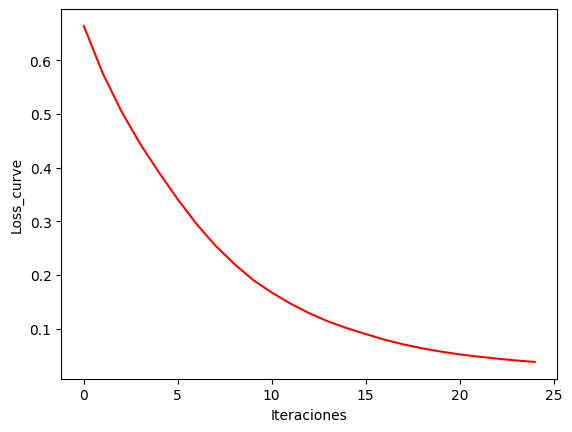

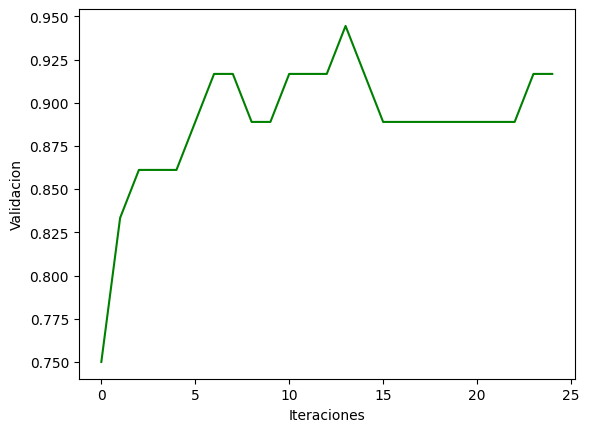

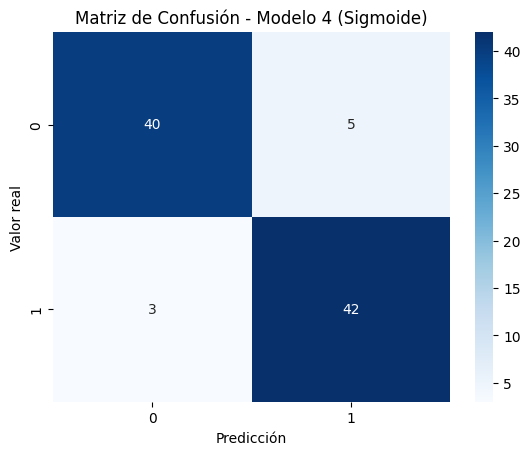

In [ ]:

#se debera realizar una estandarizacion de los datos, para el entrenamiento de las redes neuronales,


scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, Y, random_state=42, test_size=0.20, stratify=Y)

# en este modelo se usa la optimizacion de adam y funcion de activacion de ReLu

baseRed = MLPClassifier(
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    activation='relu'
)

parameter_grid = {
    'hidden_layer_sizes': [
        (10, 10, 10),  # Tu arquitectura original
        (64,),           # 1 capa de 50
        (256,),          # 1 capa de 100
        (64,128, 256)         # 2 capas
    ],
    'activation': ['relu'],
    'alpha': [0.0001, 0.001]           # Diferentes valores de regularización
}
grid_search = GridSearchCV(
    estimator=baseRed,
    param_grid=parameter_grid,
    cv=5,
    scoring='accuracy', # Buscamos la mejor
    #verbose=2,          # Muestra el progreso
    n_jobs=-1           # Usa todos los procesadores
)

grid_search.fit(X_train, y_train)

print("\nMejores parámetros encontrados:")
print(grid_search.best_params_)

red_neuronal = grid_search.best_estimator_

predicciones = red_neuronal.predict(X_test)

precision = accuracy_score(y_test,predicciones)
print('Nuestra precision sera: ', precision)

matrizConfusion = confusion_matrix(y_test,predicciones)
print("Matriz confusion (TN, FP)(FN, TP)\n", matrizConfusion)

reporte = classification_report(y_test, predicciones)
print(reporte)

validacion= red_neuronal.validation_scores_
perdida = red_neuronal.loss_curve_
plt.xlabel('Iteraciones')
plt.ylabel('Loss_curve')
plt.plot(perdida, color='red')
plt.show()


plt.xlabel('Iteraciones')
plt.ylabel('Validacion')
plt.plot(validacion, color='green')
plt.show()

sns.heatmap(matrizConfusion, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Modelo 4 (Sigmoide)")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()


¿Qué función de activación se puede elegir (sigmoid, tanh, ReLU) y cómo
impacta en la propagación del gradiente?
    
    Sigmoid: La funcion de activacion de sigmoide, lo que hace es aplastar los datos entre 0 y 1, la misma es recomendada usar para los problemas de clasificacion y generalmente se la usa para capa de salida para una clasificacion binaria. En el gradiente, sufrira lo que se conoce como gradiente desvanecido, ya que la derivada de la funcion sigmoide es muy pequeña, lo que hace que no pueda detectar el minimo
    
    tanh: La funcion de tangente hiperbolica lo que hace es aplastar los datos de salida entre -1 y 1, tiene el problema de gradiente desvanecido, ya que tambien las derivadas que brinda este suelen ser pequeñas, haciendo que la red no pueda ajustar sus pesos de manera correcta, es decir el cambio es minimo
    
    ReLu: La misma es la mas popular, y es recomenda para las capas ocultas en la actualidad. Tiene dos opciones, si el resultado Bruto (positivo), queda como el resultado, ahora si el resultado es negativo, se coloca en 0. El mismo es mejor, porque resuelve el problema de Vanishing Gradient Problem. La función tiene la pendiente siempre en 1, esto permite que el gradiente fluya hacia atras sin encogerse
    

¿Qué algoritmo de optimización usaría (SGD, Adam, RMSprop)? ¿Por qué?

    Adam: Este es el algoritmo moderno, que se utiliza actualmente en las redes neuronales. La misma utiliza el algoritmo momentum y RMSprop, combinando ambos algoritmos para la optimizacion

    SGD (Descenso de Gradiente Estocástico): Utiliza la pendiente del gradiente, para dar un paso en la direccion correcta, no es recomendable de usar, ya que si nos encontramos en alguna funcion que brinde como un barranco, la misma va a estar saltando de un lugar al otro. Luego tenemos el algoritmo momentum, el mismo busca solamente que en cada paso, el algoritmo calcula un "vector de velocidad" (la inercia). Este vector es 90% el vector de velocidad anterior y 10% el gradiente nuevo. Luego, la red se mueve en la dirección de ese nuevo vector de velocidad.

    RMSprop (El excursionista todo-terreno): la misma intenta tener una informacion guardada de los datos, los gradientes que se usaron para mejorar en cada peso, y obtiene una media de el gradiente usado para ajustar cad peso, determinando si tomar pasos mas grandes o chicos para ajustar cada peso




Mejores parámetros encontrados:
{'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (256,)}
Nuestra precision sera:  0.8222222222222222
Matriz confusion (TN, FP)(FN, TP)
 [[33 12]
 [ 4 41]]
              precision    recall  f1-score   support

           0       0.89      0.73      0.80        45
           1       0.77      0.91      0.84        45

    accuracy                           0.82        90
   macro avg       0.83      0.82      0.82        90
weighted avg       0.83      0.82      0.82        90



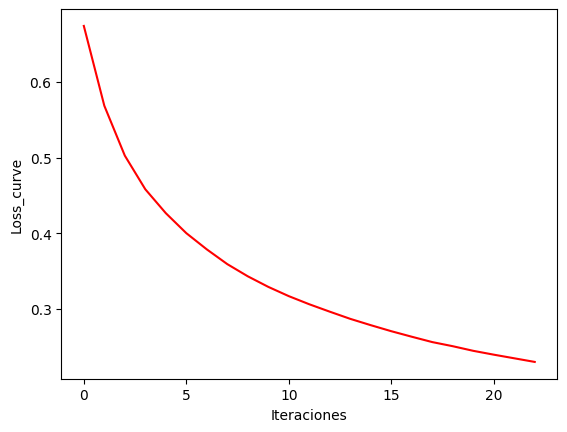

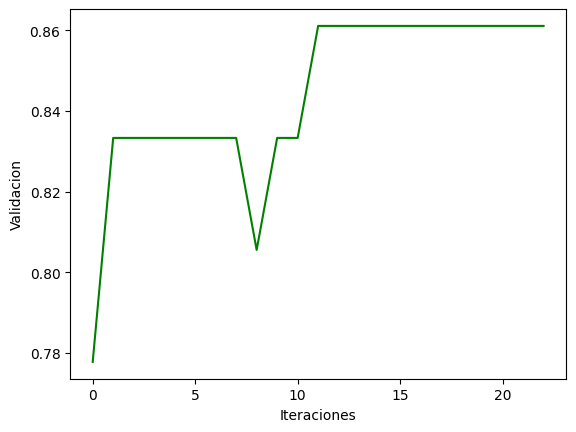

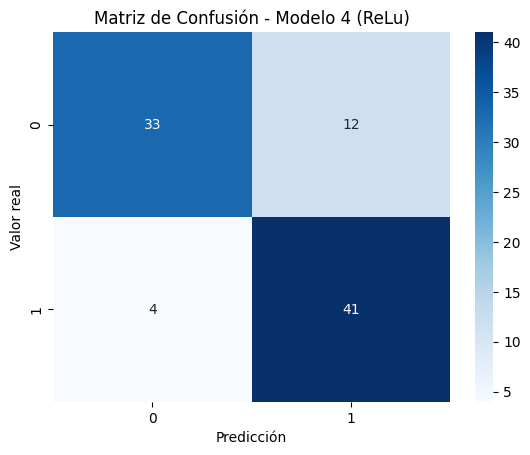

In [ ]:

baseRed = MLPClassifier(
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    activation='relu'
)

parameter_grid = {
    'hidden_layer_sizes': [
        (10, 10, 10),  # Tu arquitectura original
        (64,),           # 1 capa de 50
        (256,),          # 1 capa de 100
        (64,128, 256)         # 2 capas
    ],
    'activation': ['tanh'], # También probamos 'tanh'
    'alpha': [0.0001, 0.001]           # Diferentes valores de regularización
}
grid_search = GridSearchCV(
    estimator=baseRed,
    param_grid=parameter_grid,
    cv=5,
    scoring='accuracy', # Buscamos la mejor precisión
    #verbose=2,          # Muestra el progreso
    n_jobs=-1           # Usa todos los procesadores
)

grid_search.fit(X_train, y_train)

print("\nMejores parámetros encontrados:")
print(grid_search.best_params_)

red_neuronal = grid_search.best_estimator_

predicciones = red_neuronal.predict(X_test)

precision = accuracy_score(y_test,predicciones)
print('Nuestra precision sera: ', precision)

matrizConfusion = confusion_matrix(y_test,predicciones)
print("Matriz confusion (TN, FP)(FN, TP)\n", matrizConfusion)

reporte = classification_report(y_test, predicciones)
print(reporte)

validacion= red_neuronal.validation_scores_
perdida = red_neuronal.loss_curve_
plt.xlabel('Iteraciones')
plt.ylabel('Loss_curve')
plt.plot(perdida, color='red')
plt.show()


plt.xlabel('Iteraciones')
plt.ylabel('Validacion')
plt.plot(validacion, color='green')
plt.show()


sns.heatmap(matrizConfusion, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Modelo 4 (ReLu)")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()



Mejores parámetros encontrados:
{'activation': 'logistic', 'alpha': 0.0001, 'hidden_layer_sizes': (256,)}
Nuestra precision sera:  0.7666666666666667
Matriz confusion (TN, FP)(FN, TP)
 [[31 14]
 [ 7 38]]
              precision    recall  f1-score   support

           0       0.82      0.69      0.75        45
           1       0.73      0.84      0.78        45

    accuracy                           0.77        90
   macro avg       0.77      0.77      0.77        90
weighted avg       0.77      0.77      0.77        90



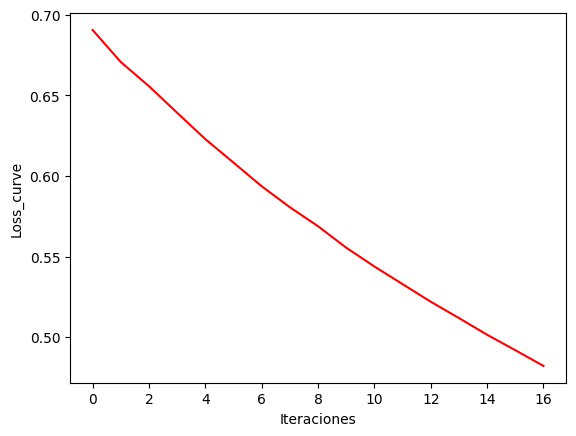

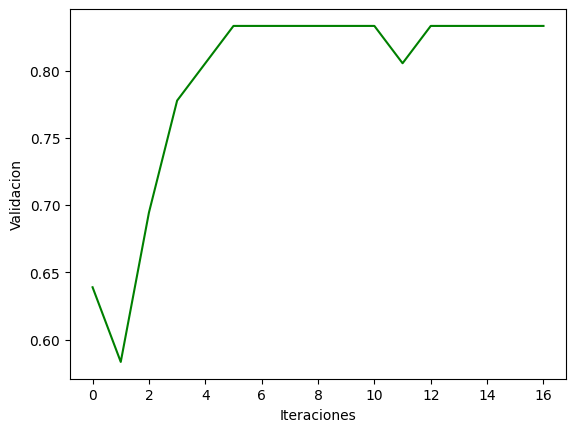

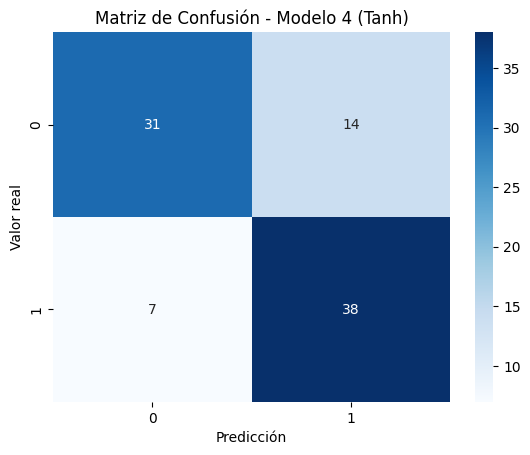

In [ ]:

baseRed = MLPClassifier(
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    activation='relu'
)

parameter_grid = {
    'hidden_layer_sizes': [
        (10, 10, 10),  # Tu arquitectura original
        (64,),           # 1 capa de 50
        (256,),          # 1 capa de 100
        (64,128, 256)         # 2 capas
    ],
    'activation': ['logistic'], # pruebo con sigmoide
    'alpha': [0.0001, 0.001]           # Diferentes valores de regularización
}
grid_search = GridSearchCV(
    estimator=baseRed,
    param_grid=parameter_grid,
    cv=5,
    scoring='accuracy', # Buscamos la mejor precisión
    #verbose=2,          # Muestra el progreso
    n_jobs=-1           # Usa todos los procesadores
)

grid_search.fit(X_train, y_train)

print("\nMejores parámetros encontrados:")
print(grid_search.best_params_)

red_neuronal = grid_search.best_estimator_

predicciones = red_neuronal.predict(X_test)

precision = accuracy_score(y_test,predicciones)
print('Nuestra precision sera: ', precision)

matrizConfusion = confusion_matrix(y_test,predicciones)
print("Matriz confusion (TN, FP)(FN, TP)\n", matrizConfusion)

reporte = classification_report(y_test, predicciones)
print(reporte)

validacion= red_neuronal.validation_scores_
perdida = red_neuronal.loss_curve_
plt.xlabel('Iteraciones')
plt.ylabel('Loss_curve')
plt.plot(perdida, color='red')
plt.show()


plt.xlabel('Iteraciones')
plt.ylabel('Validacion')
plt.plot(validacion, color='green')
plt.show()


sns.heatmap(matrizConfusion, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Modelo 4 (Tanh)")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

Nuestra precision sera:  0.7888888888888889
Matriz confusion (TN, FP)(FN, TP) [[38  7]
 [12 33]]
              precision    recall  f1-score   support

           0       0.76      0.84      0.80        45
           1       0.82      0.73      0.78        45

    accuracy                           0.79        90
   macro avg       0.79      0.79      0.79        90
weighted avg       0.79      0.79      0.79        90



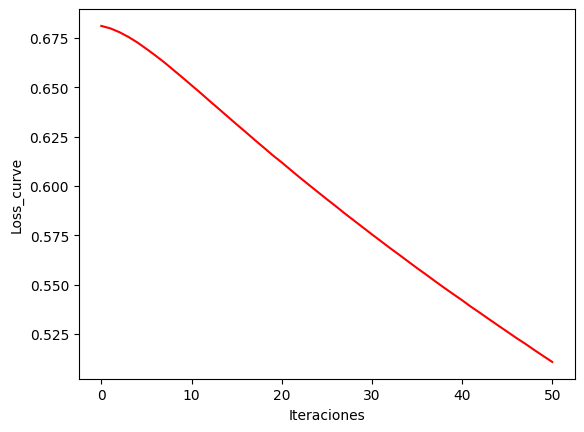

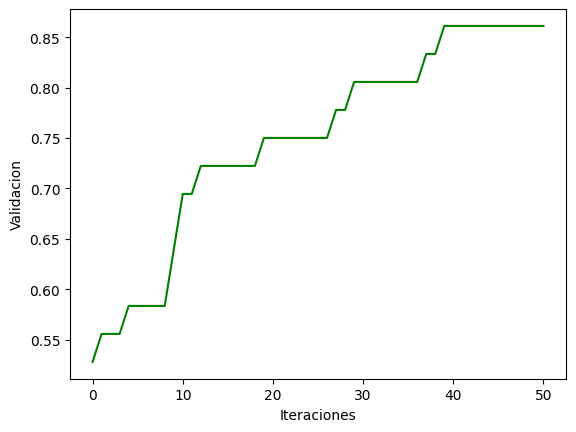

In [ ]:
#se utilizara de cada uno la funcion de activacion relu
#utilizo el algoritmo SGD
red_neuronalDos = MLPClassifier(
    solver='sgd',
    hidden_layer_sizes=(64, 128, 256),
    max_iter=1000,
    random_state=42,
    early_stopping=True
)

red_neuronalDos.fit(X_train, y_train)

predicciones = red_neuronalDos.predict(X_test)

precision = accuracy_score(y_test,predicciones)
print('Nuestra precision sera: ', precision)

matrizConfusion = confusion_matrix(y_test,predicciones)
print("Matriz confusion (TN, FP)(FN, TP)", matrizConfusion)

reporte = classification_report(y_test, predicciones)
print(reporte)

plt.xlabel('Iteraciones')
plt.ylabel('Loss_curve')
plt.plot(red_neuronalDos.loss_curve_, color='red')
plt.show()


plt.xlabel('Iteraciones')
plt.ylabel('Validacion')
plt.plot(red_neuronalDos.validation_scores_, color='green')
plt.show()

Nuestra precision sera:  0.7555555555555555
Matriz confusion (TN, FP)(FN, TP) [[31 14]
 [ 8 37]]
              precision    recall  f1-score   support

           0       0.79      0.69      0.74        45
           1       0.73      0.82      0.77        45

    accuracy                           0.76        90
   macro avg       0.76      0.76      0.75        90
weighted avg       0.76      0.76      0.75        90



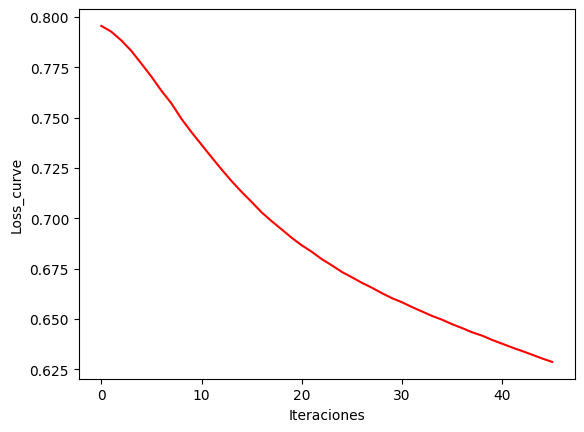

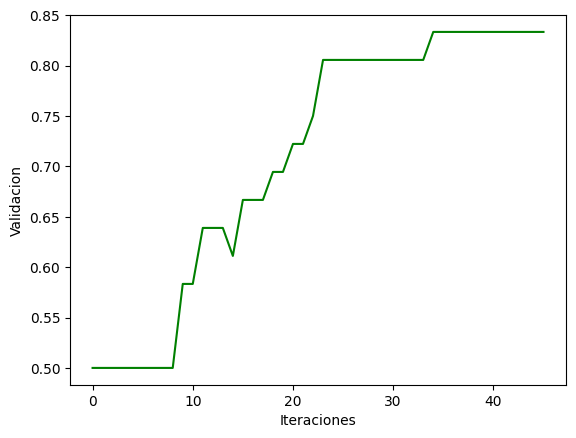

In [ ]:
#utilizo el algoritmo SGD
red_neuronalTres = MLPClassifier(
    solver='sgd',
    hidden_layer_sizes=(5,6,7),
    max_iter=1000,
    random_state=42,
    early_stopping=True
)

red_neuronalTres.fit(X_train, y_train)

predicciones = red_neuronalTres.predict(X_test)

precision = accuracy_score(y_test,predicciones)

precision = accuracy_score(y_test,predicciones)
print('Nuestra precision sera: ', precision)

matrizConfusion = confusion_matrix(y_test,predicciones)
print("Matriz confusion (TN, FP)(FN, TP)", matrizConfusion)

reporte = classification_report(y_test, predicciones)
print(reporte)

plt.xlabel('Iteraciones')
plt.ylabel('Loss_curve')
plt.plot(red_neuronalTres.loss_curve_, color='red')
plt.show()


plt.xlabel('Iteraciones')
plt.ylabel('Validacion')
plt.plot(red_neuronalTres.validation_scores_, color='green')
plt.show()